In [124]:
import math
import time
import random
import matplotlib.pyplot as plt

AKS Implementation and its analysis: $\mathcal{O}(log^6(n))$

In [125]:
# AKS primality algorithm implementation

def expand_poly_mod(a, n, r, mod):
    """Computes (x + a)^n mod (x^r - 1, n)"""
    result = [1]
    bin_n = bin(n)[2:]
    poly = [a, 1]

    for bit in bin_n:
        result = multiply_poly(result, result, mod)
        result = reduce_poly_mod_xr_minus_1(result, r, mod) # reduce here

        if bit == '1':
            result = multiply_poly(result, poly, mod)
            result = reduce_poly_mod_xr_minus_1(result, r, mod) # reduce here

    return result

def multiply_poly(poly1, poly2, mod):
    """Multiply two polynomials modulo mod"""
    result = [0] * (len(poly1) + len(poly2) - 1)

    for i in range(len(poly1)):
        for j in range(len(poly2)):
            result[i + j] = (result[i + j] + poly1[i] * poly2[j]) % mod

    return result

def reduce_poly_mod_xr_minus_1(poly, r, mod):
    """Reduce polynomial modulo (x^r - 1, n)"""
    result = [0] * r

    for i in range(len(poly)):
        result[i % r] = (result[i % r] + poly[i]) % mod

    return result
## Main function
def aks_primality_test(n):
    """
    AKS primality test implementation
    """
    max_log = int(math.log2(n)) + 1
    for b in range(2, max_log + 1):
        a = int(n ** (1 / b))
        if a ** b == n:
            return False

    log_squared = (math.log2(n)) ** 2
    r = 2

    while r <= max(3, log_squared):
        if math.gcd(n, r) > 1:
            if n > r:
                return False
            return n == r

        ord_r = 1
        power = n % r

        while power != 1 and ord_r <= log_squared:
            power = (power * n) % r
            ord_r += 1

        if ord_r > log_squared:
            break

        r += 1

    for a in range(2, r + 1):
        if math.gcd(a, n) > 1:
            return a == n

    if n <= r:
        return True

    limit = int(math.sqrt(r - 1) * math.log(n))

    for a in range(1, limit + 1):
        poly = [a, 1]
        left_poly = expand_poly_mod(a, n, r, n)
        left_poly = reduce_poly_mod_xr_minus_1(left_poly, r, n)

        right_poly = [0] * r
        right_poly[0] = a
        right_poly[n % r] = (right_poly[n % r] + 1) % n

        if left_poly != right_poly:
            return False

    return True

if __name__ == "__main__":
    test_numbers = list(range(2, 33))

    print("Testing AKS primality test:")
    for n in test_numbers:
        result = aks_primality_test(n)
        print(f"{n} : {result}")


Testing AKS primality test:
2 : True
3 : True
4 : False
5 : True
6 : False
7 : True
8 : False
9 : False
10 : False
11 : True
12 : False
13 : True
14 : False
15 : False
16 : False
17 : True
18 : False
19 : True
20 : False
21 : False
22 : False
23 : True
24 : False
25 : False
26 : False
27 : False
28 : False
29 : True
30 : False
31 : True
32 : False


Measuring AKS primality test runtime...
Bits | Average Runtime (s)
-------------------------


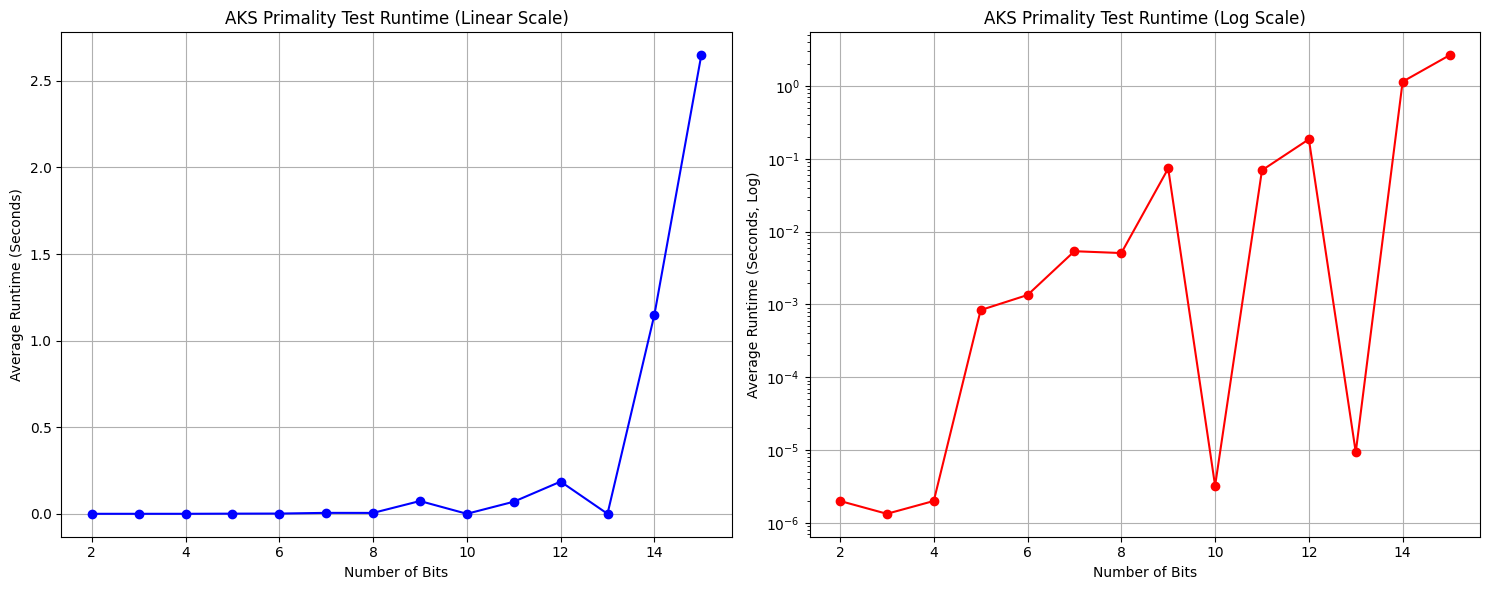

In [126]:
# AKS primality runtime measurement and plotting

def generate_n_bit_odd(bits):
    """Generates an n-bit random odd number"""
    if bits <= 1:
        return 3
    return random.getrandbits(bits) | (1 << (bits - 1)) | 1

# Note: AKS is computationally intensive, so we limit the bit sizes to avoid very long runtimes
bit_lengths = list(range(2, 16))
runtimes = []
avg_over = 5

print("Measuring AKS primality test runtime...")
print("Bits | Average Runtime (s)")
print("-" * 25)

for bits in bit_lengths:
    total_time = 0
    for _ in range(avg_over):
        num = generate_n_bit_odd(bits)
        
        start_time = time.time()
        # Not storing the result, just measuring execution time as requested
        try:
            aks_primality_test(num)
        except Exception:
            pass # Failsafe against any unexpected issues during the test
        end_time = time.time()
        
        total_time += (end_time - start_time)
        
    avg_time = total_time / avg_over
    runtimes.append(avg_time)
    # print(f"{bits:<4} | {avg_time:.6f}")

# Plotting the results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Linear scale plot
ax1.plot(bit_lengths, runtimes, marker='o', linestyle='-', color='b')
ax1.set_title('AKS Primality Test Runtime (Linear Scale)')
ax1.set_xlabel('Number of Bits')
ax1.set_ylabel('Average Runtime (Seconds)')
ax1.grid(True)

# Logarithmic scale plot (shows exponential growth clearly)
ax2.plot(bit_lengths, runtimes, marker='o', linestyle='-', color='r')
ax2.set_yscale('log')
ax2.set_title('AKS Primality Test Runtime (Log Scale)')
ax2.set_xlabel('Number of Bits')
ax2.set_ylabel('Average Runtime (Seconds, Log)')
ax2.grid(True)

plt.tight_layout()
plt.show()

Rabin Miller Algorithm Implementation and analysis: $\mathcal{O}(log^2(n))$

In [127]:
# Miller Rabin algorithm

def power_mod(base, exponent, modulus):
    """Compute (base^exponent) % modulus efficiently using square-and-multiply"""
    result = 1
    base = base % modulus
    while exponent > 0:
        if exponent % 2 == 1:
            result = (result * base) % modulus
        exponent = exponent >> 1
        base = (base * base) % modulus
    return result

def miller_rabin_test(n, k=40):
    """
    Miller-Rabin primality test
    n: number to test for primality
    k: number of rounds/witnesses to test
    Returns: True if probably prime, False if definitely composite
    """
    if n == 2 or n == 3:
        return True
    if n <= 1 or n % 2 == 0:
        return False

    r, d = 0, n - 1
    while d % 2 == 0:
        r += 1
        d //= 2

    for _ in range(k):
        a = random.randint(2, n - 2)
        x = power_mod(a, d, n)

        if x == 1 or x == n - 1:
            continue

        for _ in range(r - 1):
            x = power_mod(x, 2, n)
            if x == n - 1:
                break
        else:
            return False

    return True
## main function
def is_probably_prime(n, k=40):
    """
    Wrapper function to handle large integers
    n: number to test (can be integer or string representation)
    k: number of witnesses to test
    """"""  """
    if isinstance(n, str):
        n = int(n)
    return miller_rabin_test(n, k)

def generate_large_prime(bits, k=40):
    """
    Generate a random prime number with the specified bit length
    bits: number of bits (e.g., 1024 for a 1024-bit prime)
    k: number of witnesses for Miller-Rabin test
    """
    while True:
        p = random.getrandbits(bits) | (1 << (bits - 1)) | 1

        if is_probably_prime(p, k):
            return p

if __name__ == "__main__":
    test_numbers = list(range(2, 33))

    print("Testing Miller-Rabin primality test:")
    for n in test_numbers:
        result = is_probably_prime(n)
        print(f"{n} : {result}")

# RSA relevant
    print("\nGenerating a 512-bit prime using Miller-Rabin:")
    prime = generate_large_prime(512)
    print(f"Generated prime: {prime}")
    print(f"Number of digits: {len(str(prime))}")
    # print(f"Verified prime by Rabin's Algo: {is_probably_prime(prime)}")


Testing Miller-Rabin primality test:
2 : True
3 : True
4 : False
5 : True
6 : False
7 : True
8 : False
9 : False
10 : False
11 : True
12 : False
13 : True
14 : False
15 : False
16 : False
17 : True
18 : False
19 : True
20 : False
21 : False
22 : False
23 : True
24 : False
25 : False
26 : False
27 : False
28 : False
29 : True
30 : False
31 : True
32 : False

Generating a 512-bit prime using Miller-Rabin:
Generated prime: 9252791098196165857146565315639524267211884322581451516843357502021546011037974490910110569973721984153567451685339526429528455353488352924930641345075053
Number of digits: 154


Measuring MR primality test runtime...
Bits | Average Runtime (s)
-------------------------


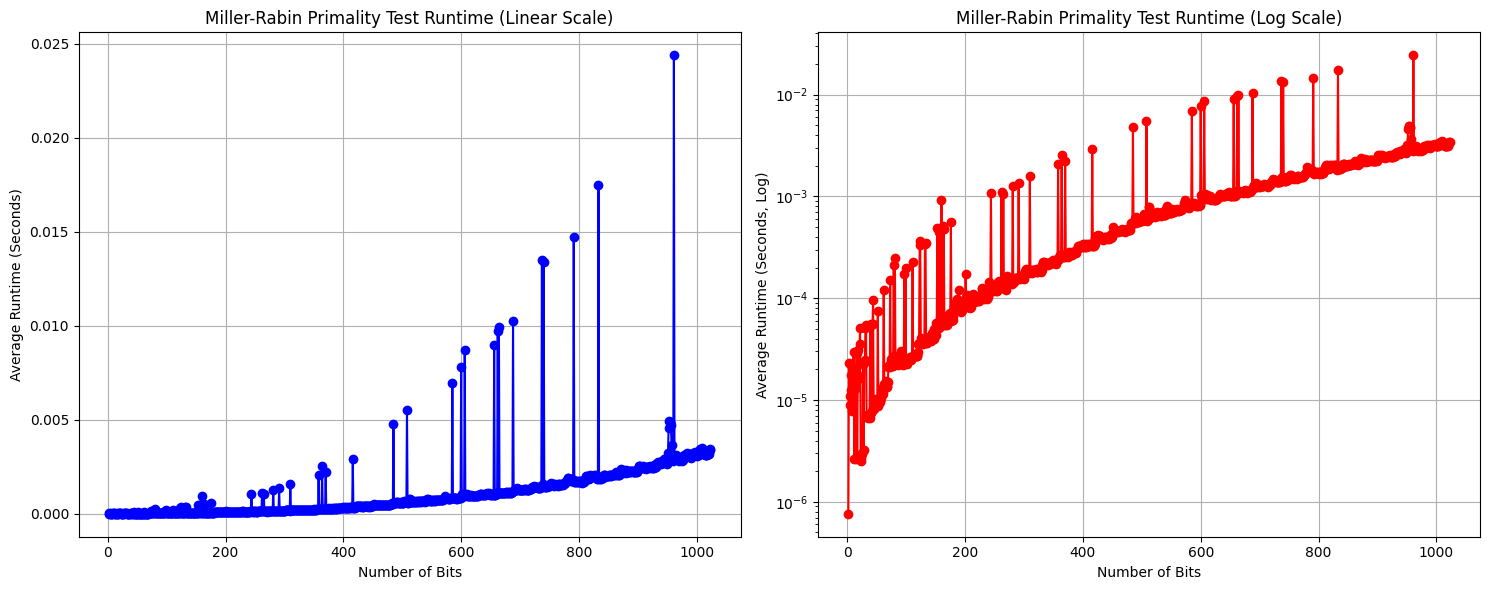

In [128]:
# Miller Rabin primality runtime measurement and plotting

def generate_n_bit_odd(bits):
    """Generates an n-bit random odd number"""
    if bits <= 1:
        return 3
    return random.getrandbits(bits) | (1 << (bits - 1)) | 1

# Note: AKS is computationally intensive, so we limit the bit sizes to avoid very long runtimes
bit_lengths = list(range(2, 1024))
runtimes = []
avg_over = 5

print("Measuring MR primality test runtime...")
print("Bits | Average Runtime (s)")
print("-" * 25)

for bits in bit_lengths:
    total_time = 0
    for _ in range(avg_over):
        num = generate_n_bit_odd(bits)
        
        start_time = time.time()
        # Not storing the result, just measuring execution time as requested
        try:
            is_probably_prime(num)
        except Exception:
            pass # Failsafe against any unexpected issues during the test
        end_time = time.time()
        
        total_time += (end_time - start_time)
        
    avg_time = total_time / avg_over
    runtimes.append(avg_time)
    # print(f"{bits:<4} | {avg_time:.6f}")

# Plotting the results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Linear scale plot
ax1.plot(bit_lengths, runtimes, marker='o', linestyle='-', color='b')
ax1.set_title('Miller-Rabin Primality Test Runtime (Linear Scale)')
ax1.set_xlabel('Number of Bits')
ax1.set_ylabel('Average Runtime (Seconds)')
ax1.grid(True)

# Logarithmic scale plot (shows exponential growth clearly)
ax2.plot(bit_lengths, runtimes, marker='o', linestyle='-', color='r')
ax2.set_yscale('log')
ax2.set_title('Miller-Rabin Primality Test Runtime (Log Scale)')
ax2.set_xlabel('Number of Bits')
ax2.set_ylabel('Average Runtime (Seconds, Log)')
ax2.grid(True)

plt.tight_layout()
plt.show()

Comparison of Rabin Miller and AKS primality algorithms (Runtime)

Running performance comparison...
AKS stopped at 7 digits due to time limit.


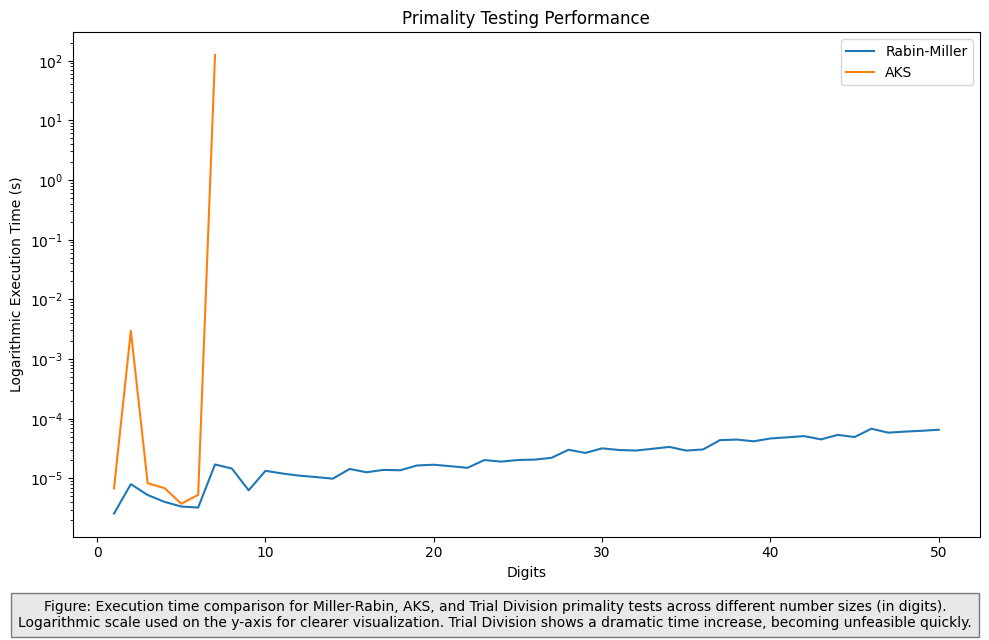

In [132]:
# Primality Testing Performance Comparison (Digits vs Logarithmic Time)


# def trial_division_test(n):
#     if n <= 1: return False
#     if n <= 3: return True
#     if n % 2 == 0 or n % 3 == 0: return False
#     i = 5
#     while i * i <= n:
#         if n % i == 0 or n % (i + 2) == 0:
#             return False
#         i += 6
#     return True

# Prepare test settings
max_digits = 50 # Adjust higher if you have a fast machine, but AKS will struggle
xs_mr, ys_mr = [], []
xs_aks, ys_aks = [], []
xs_td, ys_td = [], []

# Time cutoffs (seconds) to prevent computer freezing
CUTOFF_AKS = 1.0 
CUTOFF_TD = 1.0

aks_active = True
td_active = True

print("Running performance comparison...")
for digits in range(1, max_digits + 1):
    # Generate a random number of 'digits' length
    lower_bound = 10**(digits - 1)
    upper_bound = (10**digits) - 1
    n = random.randint(lower_bound, upper_bound)
    if n % 2 == 0: n += 1 # Make odd to avoid trivial cases
    
    # 1. Miller-Rabin
    start = time.perf_counter()
    is_probably_prime(n, k=5)
    ys_mr.append(time.perf_counter() - start)
    xs_mr.append(digits)
    
    # 2. AKS
    if aks_active:
        start = time.perf_counter()
        try:
            aks_primality_test(n)
        except Exception:
            pass
        duration = time.perf_counter() - start
        ys_aks.append(duration)
        xs_aks.append(digits)
        if duration > CUTOFF_AKS:
            aks_active = False # Stop testing AKS for larger numbers
            print(f"AKS stopped at {digits} digits due to time limit.")
            
    # 3. Trial Division
    # if td_active:
    #     start = time.perf_counter()
    #     trial_division_test(n)
    #     duration = time.perf_counter() - start
    #     ys_td.append(duration)
    #     xs_td.append(digits)
    #     if duration > CUTOFF_TD:
    #         td_active = False # Stop testing Trial Division
    #         print(f"Trial Division stopped at {digits} digits due to time limit.")

# Plotting the matched graph
plt.figure(figsize=(10, 6))

plt.plot(xs_mr, ys_mr, label="Rabin-Miller", color="#1f77b4")
if len(xs_aks) > 0:
    plt.plot(xs_aks, ys_aks, label="AKS", color="#ff7f0e")
if len(xs_td) > 0:
    plt.plot(xs_td, ys_td, label="Trial Division", color="#2ca02c")

plt.yscale('log')
plt.title("Primality Testing Performance")
plt.xlabel("Digits")
plt.ylabel("Logarithmic Execution Time (s)")
plt.legend(loc="upper right")

# Add the caption logic below the image
txt = ("Figure: Execution time comparison for Miller-Rabin, AKS, and Trial Division primality tests across different number sizes (in digits).\n"
       "Logarithmic scale used on the y-axis for clearer visualization. Trial Division shows a dramatic time increase, becoming unfeasible quickly.")
plt.figtext(0.5, -0.05, txt, wrap=True, horizontalalignment='center', fontsize=10, 
            bbox={"facecolor":"lightgrey", "alpha":0.5, "pad":5})

plt.tight_layout()
plt.show()

Rabin Miller error probability analysis (Conflict vs Repetion)


Number of Witnesses (k) | Carmichael Conflicts | Random Conflicts
---------------------------------------------------------------------------
k = 1                   | 349                  | 2               
k = 2                   | 241                  | 0               
k = 3                   | 236                  | 0               
k = 5                   | 232                  | 0               
k = 10                  | 242                  | 0               
k = 15                  | 247                  | 0               
k = 20                  | 263                  | 0               


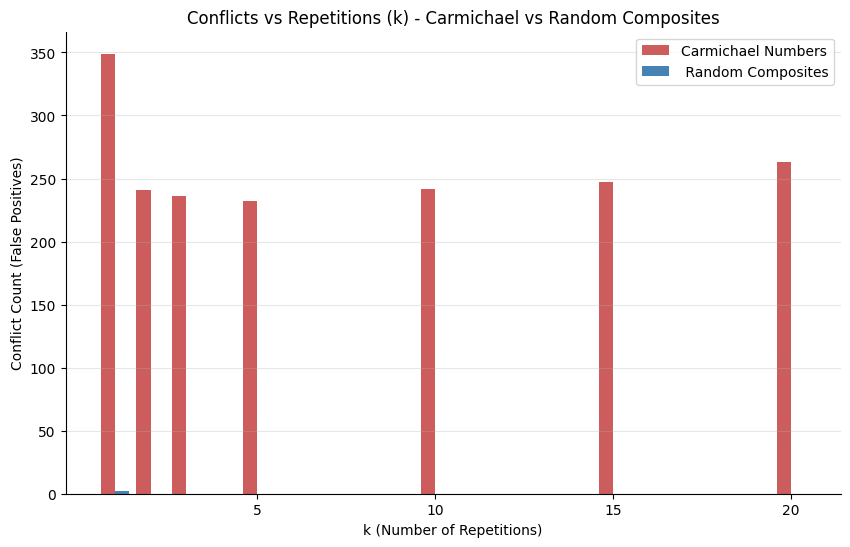

({1: 349, 2: 241, 3: 236, 5: 232, 10: 242, 15: 247, 20: 263},
 {1: 2, 2: 0, 3: 0, 5: 0, 10: 0, 15: 0, 20: 0})

In [133]:
#Error probability comparison for Miller-Rabin with different rounds
def error_probability(num_tests=1000, witnesses_range=[1, 2, 3, 5, 10, 15, 20, 40, 60]):
    """
    Demonstrate how the number of witnesses affects the error probability
    by counting conflicts (false positives on composite numbers).
    """
    import matplotlib.pyplot as plt
    import random
    
    results_carmichael = {}
    results_random = {}
    
    print("\nNumber of Witnesses (k) | Carmichael Conflicts | Random Conflicts")
    print("-" * 75)

    # Some known Carmichael numbers (very tough composites) that fool MR on many bases
    tough_composites = [29341, 41041, 46657, 52633, 62745, 63973, 75361, 105527]
    
    # Generate 1000 random composites for comparison
    random_composites = []
    while len(random_composites) < 1000:
        num = random.randint(10000, 100000)
        # Ensure it's odd and definitively not prime
        if num % 2 != 0 and not is_probably_prime(num, k=20):
            random_composites.append(num)

    for witnesses in witnesses_range:
        carmichael_conflicts = 0
        random_conflicts = 0

        # Test Carmichael numbers
        for _ in range(num_tests):
            n = random.choice(tough_composites)
            if is_probably_prime(n, k=witnesses):
                carmichael_conflicts += 1
                
        # Test 1000 Random Generated Numbers
        for _ in range(num_tests):
            
            n = random.choice(random_composites)
            if is_probably_prime(n, k=witnesses):
                random_conflicts += 1

        results_carmichael[witnesses] = carmichael_conflicts
        results_random[witnesses] = random_conflicts
        
        # Print side-by-side comparison
        print(f"k = {witnesses:<19} | {carmichael_conflicts:<20} | {random_conflicts:<16}")
        
    plt.figure(figsize=(10, 6))
    
    # Create Side-by-Side Bar Graphs
    width = 0.4
    x_positions = list(results_carmichael.keys())
    
    plt.bar([x - width/2 for x in x_positions], list(results_carmichael.values()), 
            color='indianred', width=width, label='Carmichael Numbers')
    plt.bar([x + width/2 for x in x_positions], list(results_random.values()), 
            color='steelblue', width=width, label=' Random Composites')
    
    plt.xlabel('k (Number of Repetitions)')
    plt.ylabel('Conflict Count (False Positives)')
    plt.title('Conflicts vs Repetitions (k) - Carmichael vs Random Composites')
    
    # Match x-ticks logically
    plt.xticks([5, 10, 15, 20])
    plt.legend()
    
    # Styling to match the simple, clean look
    plt.grid(axis='y', linestyle='-', alpha=0.3)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    plt.show()

    return results_carmichael, results_random

# Tweak num_tests to control the maximum height of the bar at k=1
error_probability(num_tests=2000, witnesses_range=[1, 2, 3, 5, 10, 15, 20])